# Phase 1 — Exploration des Données : DATASET-2025
## Système de Surveillance Intelligent — Bourse de Casablanca

**Objectif :** Analyser les 4 feuilles du fichier DATASET-2025.xlsx afin de :
- Identifier les variables clés (prix, volume, variation...)
- Distinguer le niveau marché global et le niveau instrument
- Détecter les premières anomalies visuelles
- Préparer les bases pour le calcul des indicateurs

**Feuilles disponibles :**
| Feuille | Contenu | Niveau |
|---|---|---|
| `Indicateurs` | Volumes journaliers agrégés | Marché global |
| `Indices` | MASI & MASI 20 quotidiens | Marché global |
| `Cours` | Prix OHLC + volumes par instrument | Instrument |
| `Intraday` | Transactions tick-by-tick (Déc. 2025) | Instrument |

---
## 0. Imports et Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

DATA_PATH = r'../data/DATASET-2025.xlsx'
print('✓ Environnement prêt')

✓ Environnement prêt


---
## 1. Chargement des Données

In [2]:
print('Chargement du fichier Excel...')
xf = pd.ExcelFile(DATA_PATH)
print(f'Feuilles disponibles : {xf.sheet_names}\n')

# --- Feuille 1 : Indicateurs marché global ---
df_ind = pd.read_excel(xf, sheet_name='Indicateurs', parse_dates=['Jour'])
df_ind.columns = ['Jour', 'Volume_MAD', 'Quantite_Titres', 'Nb_Contrats']
df_ind = df_ind.sort_values('Jour').reset_index(drop=True)

# --- Feuille 2 : Indices MASI & MASI 20 ---
df_idx = pd.read_excel(xf, sheet_name='Indices', parse_dates=['Jour'])
df_idx.columns = ['Jour', 'Code_Indice', 'Libelle', 'Variation_Veille_pct',
                   'Variation_YTD_pct', 'Cours_Haut', 'Cours_Bas']
df_idx['Code_Indice'] = df_idx['Code_Indice'].str.strip()
df_idx = df_idx.sort_values(['Jour', 'Code_Indice']).reset_index(drop=True)

# --- Feuille 3 : Cours par instrument ---
df_cours = pd.read_excel(xf, sheet_name='Cours', parse_dates=['Jour'])
df_cours = df_cours.drop(columns=[c for c in df_cours.columns if 'Unnamed' in str(c)])
df_cours.columns = ['Jour', 'Code_Valeur', 'Ticker', 'Libelle', 'Cours_Ref',
                     'Cours_Cloture', 'Meilleure_Offre', 'Meilleure_Demande',
                     'Capitalisation', 'Cours_Bas', 'Cours_Haut',
                     'Volume_MAD', 'Quantite_Titres', 'Nb_Contrats']
df_cours['Ticker'] = df_cours['Ticker'].str.strip()
df_cours = df_cours.sort_values(['Jour', 'Ticker']).reset_index(drop=True)

# --- Feuille 4 : Transactions Intraday ---
df_intra = pd.read_excel(xf, sheet_name='Intraday', parse_dates=['Jour'])
df_intra.columns = ['Jour', 'Quantite_Titres', 'Nb_Contrats', 'Ticker',
                     'Libelle', 'Sens', 'Heure_Transaction', 'Cours_Transaction',
                     'Num_Transaction']
df_intra['Ticker'] = df_intra['Ticker'].str.strip()
df_intra['Heure'] = pd.to_datetime(df_intra['Heure_Transaction']).dt.time
df_intra = df_intra.sort_values(['Jour', 'Heure_Transaction']).reset_index(drop=True)

print('✓ Toutes les feuilles chargées')

Chargement du fichier Excel...


Feuilles disponibles : ['Indicateurs', 'Indices', 'Cours', 'Intraday']



✓ Toutes les feuilles chargées


---
## 2. Vue d'Ensemble — Shape, Dtypes, Valeurs Manquantes

In [3]:
datasets = {
    'Indicateurs (Marché global)': df_ind,
    'Indices (MASI & MASI20)': df_idx,
    'Cours (Par instrument)': df_cours,
    'Intraday (Transactions)': df_intra
}

print('=' * 65)
print(f'{'Feuille':<35} {'Lignes':>8} {'Colonnes':>10} {'Nulls':>10}')
print('=' * 65)
for name, df in datasets.items():
    print(f'{name:<35} {len(df):>8,} {len(df.columns):>10} {df.isnull().sum().sum():>10,}')
print('=' * 65)

Feuille                               Lignes   Colonnes      Nulls
Indicateurs (Marché global)              247          4          0
Indices (MASI & MASI20)                  494          7          0
Cours (Par instrument)                19,164         14     17,908
Intraday (Transactions)              403,466         10          0


In [4]:
print('\n=== INDICATEURS — Types & Nulls ===')
display(df_ind.dtypes.to_frame('dtype').join(df_ind.isnull().sum().to_frame('nulls')))

print('\n=== INDICES — Types & Nulls ===')
display(df_idx.dtypes.to_frame('dtype').join(df_idx.isnull().sum().to_frame('nulls')))

print('\n=== COURS — Types & Nulls ===')
display(df_cours.dtypes.to_frame('dtype').join(df_cours.isnull().sum().to_frame('nulls')))

print('\n=== INTRADAY — Types & Nulls ===')
display(df_intra.dtypes.to_frame('dtype').join(df_intra.isnull().sum().to_frame('nulls')))


=== INDICATEURS — Types & Nulls ===


,dtype,nulls
Jour,datetime64[ns],0
Volume_MAD,float64,0
Quantite_Titres,int64,0
Nb_Contrats,int64,0



=== INDICES — Types & Nulls ===


,dtype,nulls
Jour,datetime64[ns],0
Code_Indice,object,0
Libelle,object,0
Variation_Veille_pct,float64,0
Variation_YTD_pct,float64,0
Cours_Haut,float64,0
Cours_Bas,float64,0



=== COURS — Types & Nulls ===


,dtype,nulls
Jour,datetime64[ns],0
Code_Valeur,int64,0
Ticker,object,0
Libelle,object,0
Cours_Ref,float64,0
Cours_Cloture,float64,768
Meilleure_Offre,float64,1066
Meilleure_Demande,float64,1114
Capitalisation,float64,0
Cours_Bas,float64,2992



=== INTRADAY — Types & Nulls ===


,dtype,nulls
Jour,datetime64[ns],0
Quantite_Titres,int64,0
Nb_Contrats,int64,0
Ticker,object,0
Libelle,object,0
Sens,object,0
Heure_Transaction,datetime64[ns],0
Cours_Transaction,float64,0
Num_Transaction,object,0
Heure,object,0


---
## 3. FEUILLE 1 — Indicateurs Marché Global
> **Niveau : Marché Global | Granularité : Journalière**

In [5]:
print(f'Période : {df_ind["Jour"].min().date()} → {df_ind["Jour"].max().date()}')
print(f'Nombre de séances : {len(df_ind)}')
print()
display(df_ind.describe())

Période : 2025-01-02 → 2025-12-31
Nombre de séances : 247



,Jour,Volume_MAD,Quantite_Titres,Nb_Contrats
count,247,247.00,247.00,247.00
mean,2025-07-02 12:08:44.696356352,"489,006,783.57","1,636,707.94","5,483.53"
min,2025-01-02 00:00:00,"66,424,365.95","265,031.00","1,794.00"
25%,2025-04-02 12:00:00,"291,840,811.15","928,588.00","3,820.00"
50%,2025-07-02 00:00:00,"428,109,975.22","1,439,925.00","4,743.00"
75%,2025-10-02 12:00:00,"582,881,028.49","2,057,576.00","6,508.00"
max,2025-12-31 00:00:00,"3,352,763,404.75","6,312,888.00","27,089.00"
std,NaN,"324,791,480.26","1,005,235.99","3,009.04"


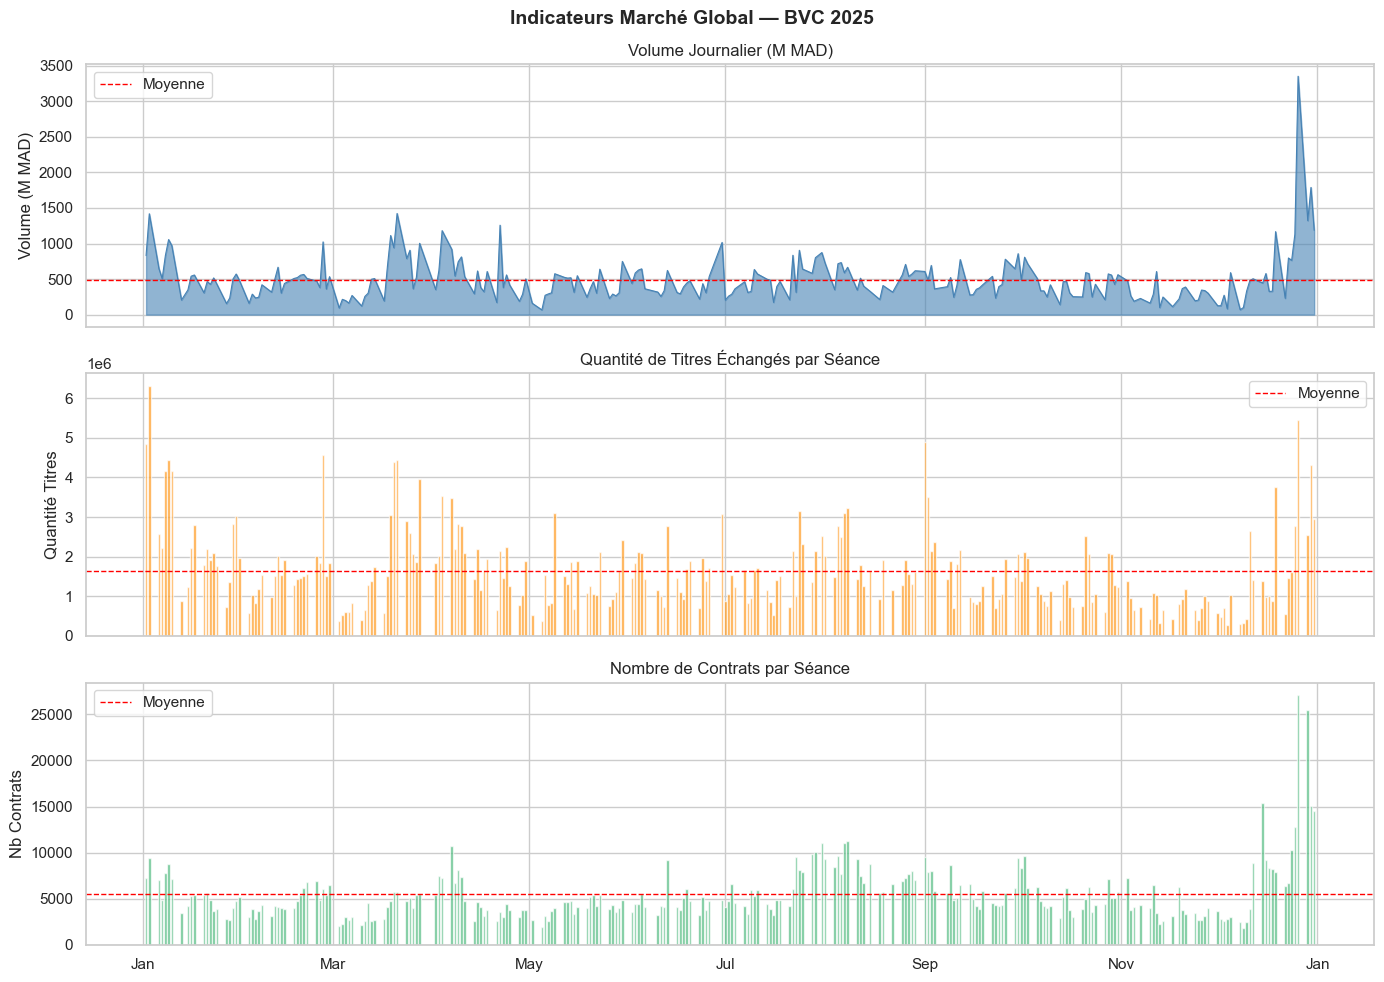

✓ Graphique sauvegardé


In [6]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle('Indicateurs Marché Global — BVC 2025', fontsize=14, fontweight='bold')

# Volume en MAD
axes[0].fill_between(df_ind['Jour'], df_ind['Volume_MAD'] / 1e6, alpha=0.6, color='steelblue')
axes[0].plot(df_ind['Jour'], df_ind['Volume_MAD'] / 1e6, color='steelblue', linewidth=0.8)
axes[0].axhline(df_ind['Volume_MAD'].mean() / 1e6, color='red', linestyle='--', linewidth=1, label='Moyenne')
axes[0].set_ylabel('Volume (M MAD)')
axes[0].legend()
axes[0].set_title('Volume Journalier (M MAD)')

# Quantité de titres
axes[1].bar(df_ind['Jour'], df_ind['Quantite_Titres'], color='darkorange', alpha=0.7, width=0.8)
axes[1].axhline(df_ind['Quantite_Titres'].mean(), color='red', linestyle='--', linewidth=1, label='Moyenne')
axes[1].set_ylabel('Quantité Titres')
axes[1].legend()
axes[1].set_title('Quantité de Titres Échangés par Séance')

# Nb Contrats
axes[2].bar(df_ind['Jour'], df_ind['Nb_Contrats'], color='mediumseagreen', alpha=0.7, width=0.8)
axes[2].axhline(df_ind['Nb_Contrats'].mean(), color='red', linestyle='--', linewidth=1, label='Moyenne')
axes[2].set_ylabel('Nb Contrats')
axes[2].legend()
axes[2].set_title('Nombre de Contrats par Séance')
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b'))

plt.tight_layout()
plt.savefig('../reports/01_indicateurs_marche.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Graphique sauvegardé')

In [7]:
# Statistiques de volume par mois
df_ind['Mois'] = df_ind['Jour'].dt.month_name()
df_ind['Mois_num'] = df_ind['Jour'].dt.month
vol_mensuel = df_ind.groupby(['Mois_num', 'Mois'])['Volume_MAD'].agg(['sum', 'mean', 'std']).reset_index()
vol_mensuel.columns = ['Mois_num', 'Mois', 'Volume_Total_MAD', 'Volume_Moyen_MAD', 'Ecart_Type']
vol_mensuel['Volume_Total_MMAD'] = vol_mensuel['Volume_Total_MAD'] / 1e6

fig = px.bar(vol_mensuel, x='Mois', y='Volume_Total_MMAD',
             title='Volume Total par Mois — BVC 2025 (M MAD)',
             labels={'Volume_Total_MMAD': 'Volume (M MAD)', 'Mois': 'Mois'},
             color='Volume_Total_MMAD', color_continuous_scale='blues',
             text_auto='.0f')
fig.update_layout(showlegend=False, xaxis_categoryorder='array',
                  xaxis_categoryarray=vol_mensuel.sort_values('Mois_num')['Mois'].tolist())
fig.show()

---
## 4. FEUILLE 2 — Indices MASI & MASI 20
> **Niveau : Marché Global | Granularité : Journalière**

In [8]:
df_masi = df_idx[df_idx['Code_Indice'] == 'MASI'].copy()
df_masi20 = df_idx[df_idx['Code_Indice'] == 'MSI20'].copy()

print(f'MASI   : {len(df_masi)} séances | {df_masi["Jour"].min().date()} → {df_masi["Jour"].max().date()}')
print(f'MSI20  : {len(df_masi20)} séances | {df_masi20["Jour"].min().date()} → {df_masi20["Jour"].max().date()}')

print('\n--- MASI ---')
display(df_masi[['Variation_Veille_pct', 'Variation_YTD_pct', 'Cours_Haut', 'Cours_Bas']].describe())

print('\n--- MASI 20 ---')
display(df_masi20[['Variation_Veille_pct', 'Variation_YTD_pct', 'Cours_Haut', 'Cours_Bas']].describe())

MASI   : 247 séances | 2025-01-02 → 2025-12-31
MSI20  : 247 séances | 2025-01-02 → 2025-12-31

--- MASI ---


,Variation_Veille_pct,Variation_YTD_pct,Cours_Haut,Cours_Bas
count,247.00,247.00,247.00,247.00
mean,0.10,22.65,"18,233.90","18,017.02"
std,1.01,8.53,"1,260.28","1,264.51"
min,-5.64,2.13,"15,125.77","14,764.86"
25%,-0.41,16.32,"17,250.74","17,090.54"
50%,0.14,24.46,"18,492.40","18,291.09"
75%,0.59,28.69,"19,188.98","18,883.92"
max,3.17,36.96,"20,340.23","20,133.01"



--- MASI 20 ---


,Variation_Veille_pct,Variation_YTD_pct,Cours_Haut,Cours_Bas
count,247.00,247.00,247.00,247.00
mean,0.09,23.64,"1,485.83","1,466.21"
std,1.08,8.99,107.34,107.54
min,-5.72,2.28,"1,224.97","1,192.19"
25%,-0.43,16.99,"1,402.62","1,388.94"
50%,0.08,25.27,"1,505.51","1,481.29"
75%,0.64,30.34,"1,565.78","1,543.30"
max,3.32,39.11,"1,669.54","1,651.85"


In [9]:
fig = make_subplots(rows=3, cols=1, shared_xaxes=True,
                    subplot_titles=('MASI — Niveau (Points)', 'MASI 20 — Niveau (Points)',
                                    'Variation Journalière (%)'),
                    vertical_spacing=0.08)

# MASI
fig.add_trace(go.Scatter(x=df_masi['Jour'], y=df_masi['Cours_Haut'], name='MASI',
                          line=dict(color='royalblue', width=2)), row=1, col=1)

# MASI 20
fig.add_trace(go.Scatter(x=df_masi20['Jour'], y=df_masi20['Cours_Haut'], name='MASI 20',
                          line=dict(color='darkorange', width=2)), row=2, col=1)

# Variations journalières MASI
colors = ['crimson' if v < 0 else 'mediumseagreen' for v in df_masi['Variation_Veille_pct']]
fig.add_trace(go.Bar(x=df_masi['Jour'], y=df_masi['Variation_Veille_pct'],
                      name='Variation MASI (%)', marker_color=colors), row=3, col=1)

fig.update_layout(height=700, title_text='Évolution des Indices BVC — 2025',
                   title_font_size=14, showlegend=True)
fig.show()

In [10]:
# Performance annuelle
perf_masi = df_masi['Variation_YTD_pct'].iloc[-1]
perf_masi20 = df_masi20['Variation_YTD_pct'].iloc[-1]

print(f'Performance YTD MASI   : {perf_masi:+.2f}%')
print(f'Performance YTD MSI20  : {perf_masi20:+.2f}%')
print(f'Séances hausse MASI    : {(df_masi["Variation_Veille_pct"] > 0).sum()} / {len(df_masi)}')
print(f'Séances baisse MASI    : {(df_masi["Variation_Veille_pct"] < 0).sum()} / {len(df_masi)}')
print(f'Max variation journalière MASI : {df_masi["Variation_Veille_pct"].max():+.2f}%')
print(f'Min variation journalière MASI : {df_masi["Variation_Veille_pct"].min():+.2f}%')

Performance YTD MASI   : +27.57%
Performance YTD MSI20  : +24.53%
Séances hausse MASI    : 147 / 247
Séances baisse MASI    : 99 / 247
Max variation journalière MASI : +3.17%
Min variation journalière MASI : -5.64%


---
## 5. FEUILLE 3 — Cours par Instrument
> **Niveau : Instrument | Granularité : Journalière**

In [11]:
print(f'Période   : {df_cours["Jour"].min().date()} → {df_cours["Jour"].max().date()}')
print(f'Total lignes : {len(df_cours):,}')
instruments = df_cours['Ticker'].unique()
print(f'Instruments  : {len(instruments)} titres')
print(f'Séances      : {df_cours["Jour"].nunique()}')
print()
print('--- 5 premiers instruments ---')
display(df_cours[['Ticker', 'Libelle']].drop_duplicates().head(10))

Période   : 2025-01-02 → 2025-12-31
Total lignes : 19,164
Instruments  : 80 titres
Séances      : 247

--- 5 premiers instruments ---


,Ticker,Libelle
0,ADH,DOUJA PROM ADDOHA
1,ADI,ALLIANCES
2,AFI,AFRIC INDUSTRIES SA
3,AFM,AFMA
4,AGM,AGMA
5,AKT,AKDITAL
6,ALM,ALUMINIUM DU MAROC
7,ARD,ARADEI CAPITAL
8,ATH,AUTO HALL
9,ATL,ATLANTASANAD


In [12]:
display(df_cours[['Cours_Ref', 'Cours_Cloture', 'Meilleure_Offre', 'Meilleure_Demande',
                   'Cours_Bas', 'Cours_Haut', 'Volume_MAD', 'Quantite_Titres', 'Nb_Contrats',
                   'Capitalisation']].describe())

,Cours_Ref,Cours_Cloture,Meilleure_Offre,Meilleure_Demande,Cours_Bas,Cours_Haut,Volume_MAD,Quantite_Titres,Nb_Contrats,Capitalisation
count,"19,164.00","18,396.00","18,098.00","18,050.00","16,172.00","16,172.00","16,172.00","16,172.00","16,172.00","19,164.00"
mean,"1,051.98","1,092.65","1,092.24","1,056.64",989.71,"1,012.06","7,468,753.13","24,997.95",83.75,"12,242,969,250.37"
std,"1,360.20","1,374.60","1,390.40","1,317.31","1,243.82","1,267.36","27,712,400.14","104,772.52",299.04,"24,116,210,310.91"
min,15.92,15.92,16.29,15.86,15.81,16.30,39.93,1.00,1.00,"12,461,322.72"
25%,171.00,222.45,227.00,216.24,205.00,210.00,"75,579.80",150.00,8.00,"950,000,000.00"
50%,492.98,530.00,531.00,521.25,483.00,497.00,"723,117.80","1,540.00",26.00,"2,844,933,605.45"
75%,"1,381.00","1,469.25","1,419.00","1,426.75","1,305.00","1,331.25","5,530,703.01","11,630.75",77.00,"11,733,052,204.00"
max,"7,000.00","7,000.00","7,392.00","6,700.00","7,000.00","7,000.00","1,950,300,767.10","3,454,820.00","19,031.00","169,939,748,726.10"


In [13]:
# Calcul des variables clés par instrument
df_cours['Rendement_pct'] = df_cours.groupby('Ticker')['Cours_Cloture'].pct_change() * 100
df_cours['Range_pct'] = (df_cours['Cours_Haut'] - df_cours['Cours_Bas']) / df_cours['Cours_Ref'] * 100
df_cours['Spread_pct'] = ((df_cours['Meilleure_Offre'] - df_cours['Meilleure_Demande'])
                           / df_cours['Cours_Ref'] * 100).abs()

# Volume moyen 20 séances par instrument
df_cours['Vol_Moyen_20j'] = (df_cours.groupby('Ticker')['Volume_MAD']
                              .transform(lambda x: x.rolling(20, min_periods=5).mean()))
df_cours['Volume_Relatif'] = df_cours['Volume_MAD'] / df_cours['Vol_Moyen_20j']

print('✓ Variables calculées : Rendement, Range, Spread, Volume Relatif')
display(df_cours[['Ticker', 'Jour', 'Cours_Cloture', 'Rendement_pct',
                   'Range_pct', 'Spread_pct', 'Volume_Relatif']].dropna().head(10))

✓ Variables calculées : Rendement, Range, Spread, Volume Relatif


,Ticker,Jour,Cours_Cloture,Rendement_pct,Range_pct,Spread_pct,Volume_Relatif
308,ADH,2025-01-08,46.25,2.03,3.33,1.68,1.02
309,ADI,2025-01-08,545.00,2.83,5.09,2.64,1.09
310,AFI,2025-01-08,306.05,0.67,1.30,1.30,0.58
311,AFM,2025-01-08,"1,105.00",0.00,0.00,3.80,1.69
313,AKT,2025-01-08,"1,160.00",3.57,4.91,0.89,1.13
314,ALM,2025-01-08,"1,450.00",3.57,0.64,5.43,1.19
315,ARD,2025-01-08,483.50,-0.51,0.82,0.49,1.49
316,ATH,2025-01-08,64.90,1.09,1.56,2.32,2.04
317,ATL,2025-01-08,130.00,1.48,3.16,2.50,0.04
318,ATW,2025-01-08,614.20,1.34,2.31,0.41,0.50


In [14]:
# Top 15 titres par volume moyen
top_vol = (df_cours.groupby('Ticker')['Volume_MAD'].mean()
           .sort_values(ascending=False).head(15).reset_index())
top_vol.columns = ['Ticker', 'Volume_Moyen_MAD']

fig = px.bar(top_vol, x='Ticker', y='Volume_Moyen_MAD',
             title='Top 15 Titres par Volume Journalier Moyen (MAD) — 2025',
             labels={'Volume_Moyen_MAD': 'Volume Moyen (MAD)', 'Ticker': 'Titre'},
             color='Volume_Moyen_MAD', color_continuous_scale='viridis',
             text_auto='.2s')
fig.show()

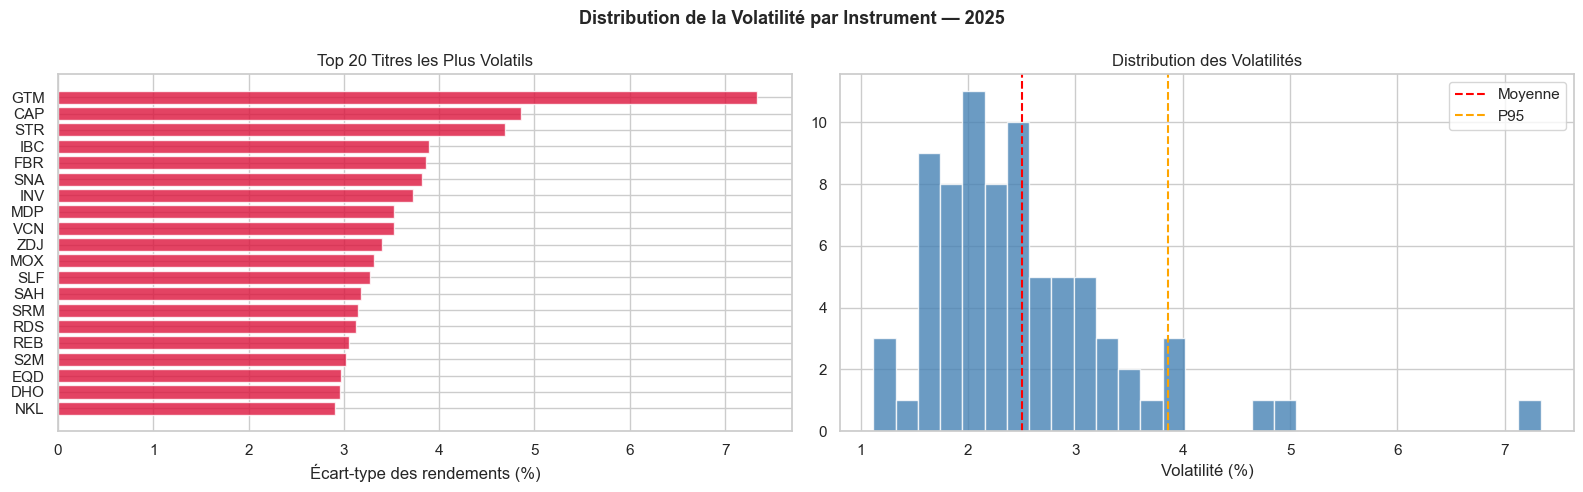

In [15]:
# Volatilité par instrument (écart-type des rendements journaliers)
vol_instr = (df_cours.groupby('Ticker')['Rendement_pct']
             .std().sort_values(ascending=False).reset_index())
vol_instr.columns = ['Ticker', 'Volatilite_pct']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Distribution de la Volatilité par Instrument — 2025', fontsize=13, fontweight='bold')

axes[0].barh(vol_instr.head(20)['Ticker'][::-1],
             vol_instr.head(20)['Volatilite_pct'][::-1], color='crimson', alpha=0.8)
axes[0].set_xlabel('Écart-type des rendements (%)')
axes[0].set_title('Top 20 Titres les Plus Volatils')

axes[1].hist(vol_instr['Volatilite_pct'].dropna(), bins=30, color='steelblue', alpha=0.8, edgecolor='white')
axes[1].axvline(vol_instr['Volatilite_pct'].mean(), color='red', linestyle='--', label='Moyenne')
axes[1].axvline(vol_instr['Volatilite_pct'].quantile(0.95), color='orange',
                linestyle='--', label='P95')
axes[1].set_xlabel('Volatilité (%)')
axes[1].set_title('Distribution des Volatilités')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/02_volatilite_instruments.png', dpi=150, bbox_inches='tight')
plt.show()

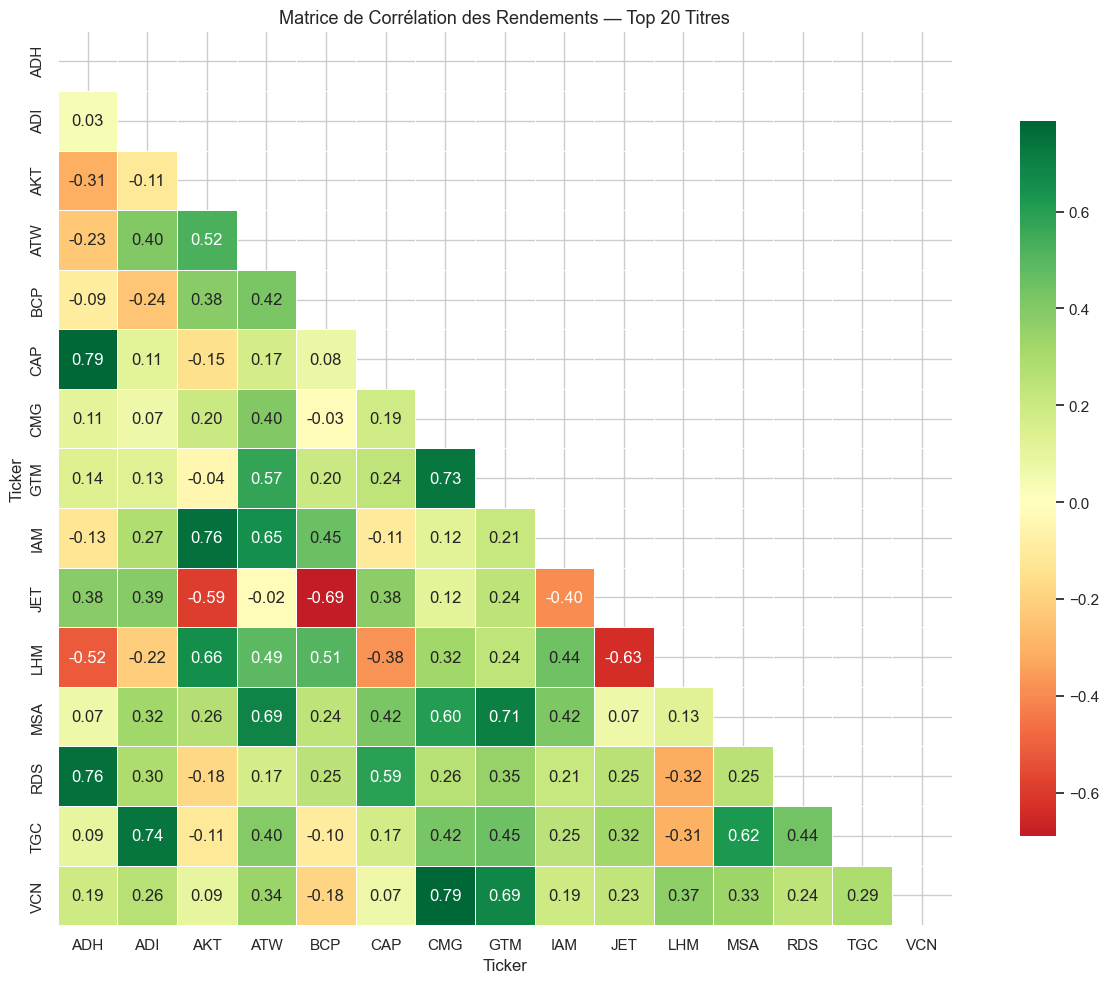

In [16]:
# Heatmap de corrélation — Cours de clôture des 20 titres les plus échangés
top20_tickers = top_vol['Ticker'].tolist()
pivot_cloture = df_cours[df_cours['Ticker'].isin(top20_tickers)].pivot_table(
    index='Jour', columns='Ticker', values='Cours_Cloture'
)
corr_matrix = pivot_cloture.pct_change().dropna().corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, mask=mask, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Matrice de Corrélation des Rendements — Top 20 Titres', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/03_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. FEUILLE 4 — Transactions Intraday (Décembre 2025)
> **Niveau : Instrument | Granularité : Tick-by-Tick**

In [17]:
print(f'Période      : {df_intra["Jour"].min().date()} → {df_intra["Jour"].max().date()}')
print(f'Total transactions : {len(df_intra):,}')
print(f'Instruments  : {df_intra["Ticker"].nunique()} titres')
print(f'Séances      : {df_intra["Jour"].nunique()}')
print(f'Sens uniques : {df_intra["Sens"].unique()} (A=Achat, V=Vente)')
print()
display(df_intra.head(5))

Période      : 2025-12-01 → 2025-12-31
Total transactions : 403,466
Instruments  : 77 titres
Séances      : 23
Sens uniques : ['A' 'V'] (A=Achat, V=Vente)



,Jour,Quantite_Titres,Nb_Contrats,Ticker,Libelle,Sens,Heure_Transaction,Cours_Transaction,Num_Transaction,Heure
0,2025-12-01,5,1,VCN,VICENNE,A,1900-01-01 09:30:03.123,476.00,T69UfPaV97,09:30:03.123000
1,2025-12-01,10,1,VCN,VICENNE,A,1900-01-01 09:30:03.123,476.00,T69UfPaV99,09:30:03.123000
2,2025-12-01,4,1,VCN,VICENNE,A,1900-01-01 09:30:03.123,476.00,T69UfPaV9a,09:30:03.123000
3,2025-12-01,1,1,VCN,VICENNE,A,1900-01-01 09:30:03.123,476.00,T69UfPaV9A,09:30:03.123000
4,2025-12-01,8,1,VCN,VICENNE,A,1900-01-01 09:30:03.123,476.00,T69UfPaV9b,09:30:03.123000


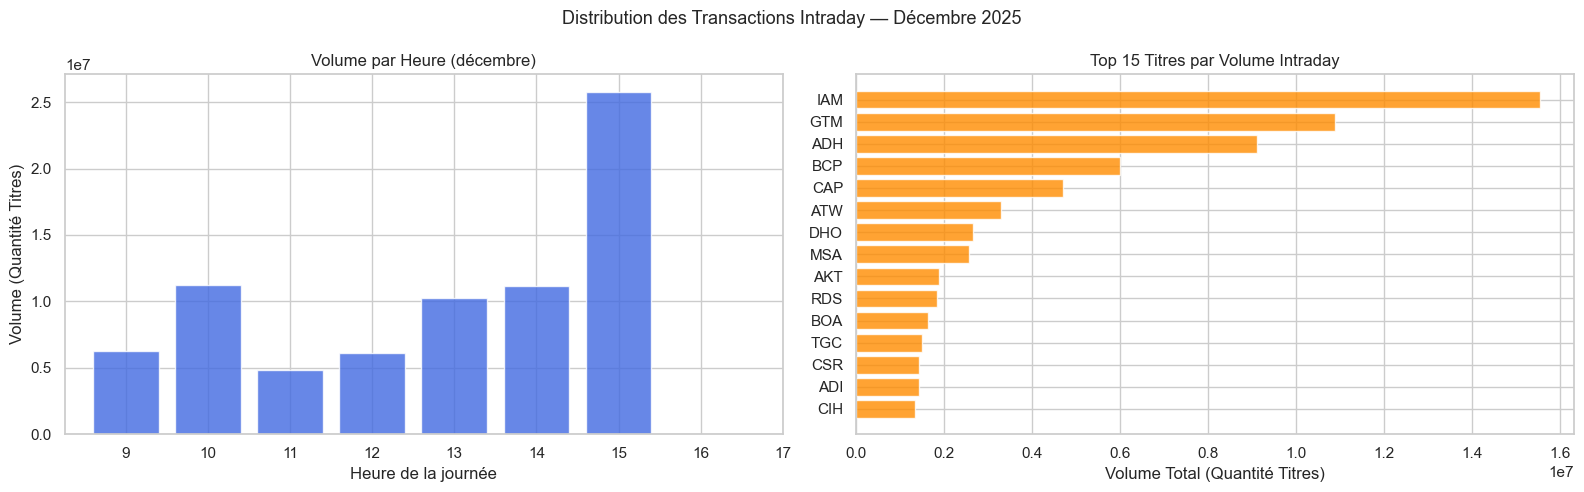

In [18]:
# Distribution des transactions par heure
df_intra['Heure_int'] = pd.to_datetime(df_intra['Heure_Transaction']).dt.hour
df_intra['Minute_int'] = pd.to_datetime(df_intra['Heure_Transaction']).dt.minute
df_intra['Heure_Decimal'] = df_intra['Heure_int'] + df_intra['Minute_int'] / 60

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Distribution des Transactions Intraday — Décembre 2025', fontsize=13)

# Par tranche horaire
tranches = df_intra.groupby('Heure_int')['Quantite_Titres'].sum()
axes[0].bar(tranches.index, tranches.values, color='royalblue', alpha=0.8, edgecolor='white')
axes[0].set_xlabel('Heure de la journée')
axes[0].set_ylabel('Volume (Quantité Titres)')
axes[0].set_title('Volume par Heure (décembre)')
axes[0].set_xticks(range(9, 18))

# Top 15 instruments par volume intraday
top_intra = (df_intra.groupby('Ticker')['Quantite_Titres'].sum()
             .sort_values(ascending=False).head(15))
axes[1].barh(top_intra.index[::-1], top_intra.values[::-1], color='darkorange', alpha=0.8)
axes[1].set_xlabel('Volume Total (Quantité Titres)')
axes[1].set_title('Top 15 Titres par Volume Intraday')

plt.tight_layout()
plt.savefig('../reports/04_intraday_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

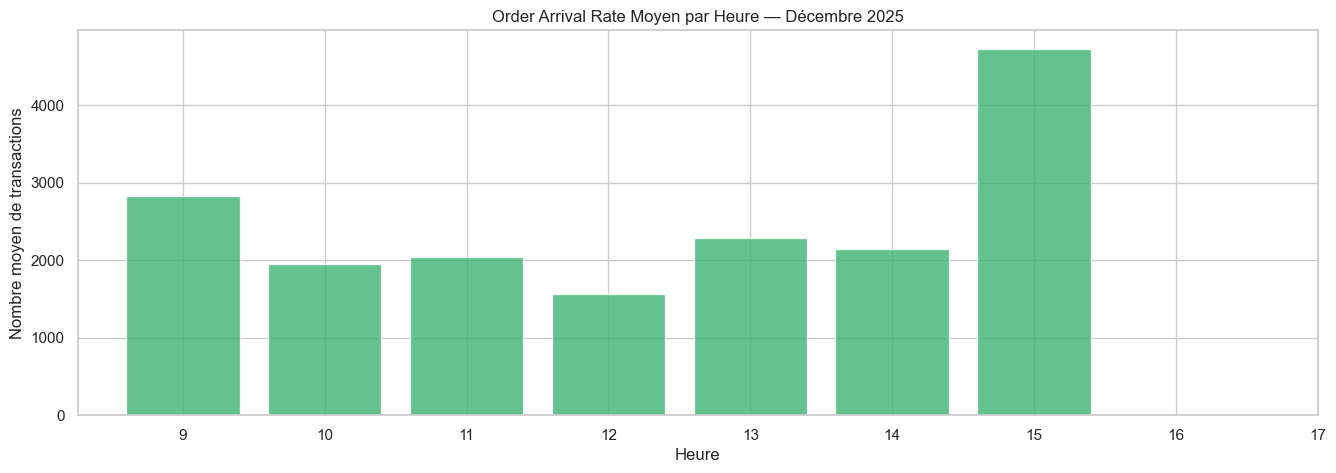

In [19]:
# Analyse Order Arrival Rate (transactions par heure par journée)
df_intra['Date'] = df_intra['Jour'].dt.date
oar = df_intra.groupby(['Date', 'Heure_int']).size().reset_index(name='Nb_Transactions')
oar_pivot = oar.pivot_table(index='Heure_int', columns='Date', values='Nb_Transactions', aggfunc='mean')

plt.figure(figsize=(16, 5))
oar_moyen = oar.groupby('Heure_int')['Nb_Transactions'].mean()
plt.bar(oar_moyen.index, oar_moyen.values, color='mediumseagreen', alpha=0.8, edgecolor='white')
plt.xlabel('Heure')
plt.ylabel('Nombre moyen de transactions')
plt.title('Order Arrival Rate Moyen par Heure — Décembre 2025')
plt.xticks(range(9, 18))
plt.savefig('../reports/05_order_arrival_rate.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# Statistiques des cours de transaction
print('--- Statistiques des Cours de Transaction ---')
display(df_intra.groupby('Ticker')['Cours_Transaction'].agg(['mean', 'std', 'min', 'max']).head(20))

--- Statistiques des Cours de Transaction ---


,mean,std,min,max
Ticker,,,,
ADH,35.36,0.71,34.00,37.40
ADI,551.60,14.09,526.30,585.00
AFI,332.40,3.81,325.00,338.00
AFM,"1,257.80",36.49,"1,207.00","1,319.00"
AGM,"6,554.00",161.28,"6,300.00","6,677.00"
AKT,"1,181.56",50.56,"1,067.00","1,340.00"
ALM,"1,788.41",32.91,"1,655.00","1,840.00"
ARD,432.34,15.44,396.00,460.00
ATH,93.49,1.66,90.00,97.00


---
## 7. Analyse de la Liquidité
> **Indicateur clé pour la surveillance du marché**

In [21]:
# Turnover Ratio = Volume_MAD / Capitalisation (proxy de liquidité)
df_cours['Turnover_Ratio'] = df_cours['Volume_MAD'] / df_cours['Capitalisation']

# Liquidité moyenne par instrument
liq = df_cours.groupby('Ticker').agg(
    Turnover_Ratio_Moyen=('Turnover_Ratio', 'mean'),
    Volume_Moyen=('Volume_MAD', 'mean'),
    Nb_Seances_Actives=('Volume_MAD', lambda x: (x > 0).sum()),
    Spread_Moyen=('Spread_pct', 'mean'),
    Nb_Seances_Total=('Jour', 'count')
).reset_index()
liq['Taux_Activite_pct'] = liq['Nb_Seances_Actives'] / liq['Nb_Seances_Total'] * 100

print('=== Classement Liquidité (Top 20) ===')
display(liq.sort_values('Turnover_Ratio_Moyen', ascending=False).head(20))

print('\n=== Titres peu liquides (Turnover < P10) ===')
seuil_liquidite = liq['Turnover_Ratio_Moyen'].quantile(0.10)
print(f'Seuil P10 Turnover Ratio : {seuil_liquidite:.6f}')
peu_liquides = liq[liq['Turnover_Ratio_Moyen'] < seuil_liquidite]
print(f'Nombre de titres peu liquides : {len(peu_liquides)}')
display(peu_liquides.sort_values('Turnover_Ratio_Moyen').head(10))

=== Classement Liquidité (Top 20) ===


,Ticker,Turnover_Ratio_Moyen,Volume_Moyen,Nb_Seances_Actives,Spread_Moyen,Nb_Seances_Total,Taux_Activite_pct
35,GTM,0.01,"391,870,676.83",12,16.72,12,100.00
72,STR,0.01,"1,565,193.37",247,5.04,247,100.00
15,CAP,0.01,"41,051,171.45",18,7.65,18,100.00
77,VCN,0.01,"23,633,923.24",115,2.36,115,100.00
58,RDS,0.00,"14,355,864.71",247,2.21,247,100.00
40,INV,0.00,"260,517.32",233,3.91,247,94.33
33,FBR,0.00,"1,772,084.74",247,3.49,247,100.00
68,SNA,0.00,"4,668,135.53",247,3.09,247,100.00
47,MDP,0.00,"407,227.93",247,3.74,247,100.00
2,AFI,0.00,"233,749.98",246,2.09,247,99.60



=== Titres peu liquides (Turnover < P10) ===
Seuil P10 Turnover Ratio : 0.000065
Nombre de titres peu liquides : 8


,Ticker,Turnover_Ratio_Moyen,Volume_Moyen,Nb_Seances_Actives,Spread_Moyen,Nb_Seances_Total,Taux_Activite_pct
54,NEJ,0.00,"12,286.38",34,22.58,247,13.77
76,UMR,0.00,"19,470.97",104,5.33,247,42.11
11,BAL,0.00,"7,328.80",113,13.05,247,45.75
49,MLE,0.00,"18,496.45",118,6.40,247,47.77
43,LES,0.00,"250,707.72",199,4.00,247,80.57
46,MAB,0.00,"42,323.01",110,4.16,247,44.53
57,PRO,0.00,"44,647.91",110,6.14,247,44.53
62,SAH,0.00,"374,054.47",197,6.19,247,79.76


---
## 8. Premières Détections Statistiques d'Anomalies
> **Seuils : Z-score > 3 | Percentile P99**

In [22]:
from scipy import stats

def detect_anomalies_zscore(serie, threshold=3.0):
    """Retourne un masque booléen des anomalies par Z-score."""
    z = np.abs(stats.zscore(serie.dropna()))
    return z > threshold

def detect_anomalies_percentile(serie, p_low=1, p_high=99):
    """Retourne un masque booléen des anomalies par percentile."""
    low = np.percentile(serie.dropna(), p_low)
    high = np.percentile(serie.dropna(), p_high)
    return (serie < low) | (serie > high)

# --- Anomalies sur volume marché global ---
vol_series = df_ind['Volume_MAD'].dropna()
z_scores_vol = np.abs(stats.zscore(vol_series))
p99_vol = np.percentile(vol_series, 99)
p01_vol = np.percentile(vol_series, 1)

df_ind['Z_Score_Volume'] = np.abs(stats.zscore(df_ind['Volume_MAD'].fillna(df_ind['Volume_MAD'].mean())))
df_ind['Anomalie_Volume_Z'] = df_ind['Z_Score_Volume'] > 3
df_ind['Anomalie_Volume_P99'] = df_ind['Volume_MAD'] > p99_vol

print('=== Anomalies Volume Marché Global ===')
print(f'Seuil P99 Volume : {p99_vol/1e6:.2f} M MAD')
print(f'Seuil P01 Volume : {p01_vol/1e6:.2f} M MAD')
print(f'Anomalies Z>3    : {df_ind["Anomalie_Volume_Z"].sum()} séances')
print(f'Anomalies P99    : {df_ind["Anomalie_Volume_P99"].sum()} séances')

display(df_ind[df_ind['Anomalie_Volume_Z']][['Jour', 'Volume_MAD', 'Z_Score_Volume']]
        .sort_values('Z_Score_Volume', ascending=False))

=== Anomalies Volume Marché Global ===
Seuil P99 Volume : 1420.73 M MAD
Seuil P01 Volume : 87.52 M MAD
Anomalies Z>3    : 2 séances
Anomalies P99    : 3 séances


,Jour,Volume_MAD,Z_Score_Volume
243,2025-12-26,"3,352,763,404.75",8.84
245,2025-12-30,"1,788,938,270.94",4.01


In [23]:
# Visualisation anomalies volume
fig = go.Figure()

# Volume normal
df_normal = df_ind[~df_ind['Anomalie_Volume_Z']]
df_anomal = df_ind[df_ind['Anomalie_Volume_Z']]

fig.add_trace(go.Bar(x=df_normal['Jour'], y=df_normal['Volume_MAD'] / 1e6,
                      name='Volume Normal', marker_color='steelblue', opacity=0.7))
fig.add_trace(go.Bar(x=df_anomal['Jour'], y=df_anomal['Volume_MAD'] / 1e6,
                      name='Anomalie Volume (Z>3)', marker_color='crimson', opacity=0.9))
fig.add_hline(y=p99_vol / 1e6, line_dash='dash', line_color='orange',
               annotation_text='Seuil P99')

fig.update_layout(title='Volume Marché Global avec Détection d\'Anomalies — BVC 2025',
                   xaxis_title='Date', yaxis_title='Volume (M MAD)',
                   barmode='overlay', height=450)
fig.show()

In [24]:
# Anomalies sur rendements par instrument
df_cours_clean = df_cours.dropna(subset=['Rendement_pct'])

def flag_anomalies_instrument(grp):
    if len(grp) < 5:
        grp['Anomalie_Rendement'] = False
        return grp
    mu, sigma = grp['Rendement_pct'].mean(), grp['Rendement_pct'].std()
    grp['Z_Rendement'] = (grp['Rendement_pct'] - mu) / sigma if sigma > 0 else 0
    grp['Anomalie_Rendement'] = grp['Z_Rendement'].abs() > 3
    return grp

df_cours = df_cours.groupby('Ticker', group_keys=False).apply(flag_anomalies_instrument)

anomalies_rendement = df_cours[df_cours['Anomalie_Rendement']].copy()
print(f'Total anomalies de rendement (Z>3) : {len(anomalies_rendement)}')
print(f'Instruments concernés : {anomalies_rendement["Ticker"].nunique()}')
display(anomalies_rendement[['Jour', 'Ticker', 'Libelle', 'Cours_Cloture',
                               'Rendement_pct', 'Z_Rendement']]
        .sort_values('Z_Rendement', ascending=False).head(20))

Total anomalies de rendement (Z>3) : 309
Instruments concernés : 60


,Jour,Ticker,Libelle,Cours_Cloture,Rendement_pct,Z_Rendement
18931,2025-12-29,ARD,ARADEI CAPITAL,435.45,9.96,7.94
9554,2025-07-03,ALM,ALUMINIUM DU MAROC,"1,979.00",9.64,6.02
9431,2025-07-01,IMO,IMMORENTE INVEST,89.88,6.73,6.01
4623,2025-03-28,AFM,AFMA,"1,334.00",9.98,5.65
9473,2025-07-02,AFI,AFRIC INDUSTRIES SA,369.55,9.99,5.57
1498,2025-01-30,IAM,ITISSALAT AL-MAGHRIB,106.30,9.58,5.52
3390,2025-03-06,AFI,AFRIC INDUSTRIES SA,335.00,9.84,5.49
12087,2025-08-22,MUT,MUTANDIS SCA,296.95,9.98,5.32
14335,2025-10-03,IMO,IMMORENTE INVEST,93.48,5.60,5.00
5388,2025-04-14,WAA,WAFA ASSURANCE,"4,505.00",9.99,4.73


In [25]:
# Anomalies de volume relatif (spike de volume)
vol_rel = df_cours.dropna(subset=['Volume_Relatif'])
p95_vr = vol_rel['Volume_Relatif'].quantile(0.95)
p99_vr = vol_rel['Volume_Relatif'].quantile(0.99)

spikes_vol = vol_rel[vol_rel['Volume_Relatif'] > p99_vr]
print(f'Seuil P95 Volume Relatif : {p95_vr:.2f}x la moyenne')
print(f'Seuil P99 Volume Relatif : {p99_vr:.2f}x la moyenne')
print(f'Volume spikes (>P99) : {len(spikes_vol)} événements')
display(spikes_vol[['Jour', 'Ticker', 'Volume_MAD', 'Vol_Moyen_20j', 'Volume_Relatif']]
        .sort_values('Volume_Relatif', ascending=False).head(20))

Seuil P95 Volume Relatif : 3.88x la moyenne
Seuil P99 Volume Relatif : 7.86x la moyenne
Volume spikes (>P99) : 158 événements


,Jour,Ticker,Volume_MAD,Vol_Moyen_20j,Volume_Relatif
18904,2025-12-26,RIS,"45,658,966.00","2,442,866.33",18.69
7502,2025-05-23,GAZ,"71,251,915.00","4,259,296.45",16.73
11855,2025-08-15,NKL,"20,590,498.72","1,234,269.35",16.68
18869,2025-12-26,CTM,"19,066,311.00","1,186,499.91",16.07
17529,2025-12-03,GAZ,"33,564,635.00","2,121,204.56",15.82
17147,2025-11-26,LES,"10,151,176.00","653,101.09",15.54
1743,2025-02-04,MOX,"2,198,635.00","148,843.75",14.77
7921,2025-05-30,SNP,"34,393,238.90","2,345,806.26",14.66
9514,2025-07-02,M2M,"5,575,669.90","389,611.13",14.31
4863,2025-04-04,BCI,"24,290,774.60","1,700,817.85",14.28


---
## 9. Synthèse — Variables Clés Identifiées

In [26]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║      SYNTHÈSE — VARIABLES CLÉS IDENTIFIÉES POUR SURVEILLANCE    ║
╠══════════════════════════════════════════════════════════════════╣
║ NIVEAU MARCHÉ GLOBAL                                             ║
║   • Volume journalier (M MAD)   ← Activité globale              ║
║   • Quantité de titres échangés ← Profondeur du marché          ║
║   • Nombre de contrats          ← Fragmentation des ordres      ║
║   • MASI / MSI20 variation (%)  ← Tendance & momentum           ║
║   • Breadth (séances H/B ratio) ← Santé du marché               ║
╠══════════════════════════════════════════════════════════════════╣
║ NIVEAU INSTRUMENT                                                ║
║   • Rendement journalier (%)    ← Signal prix                   ║
║   • Volatilité rolling (20j)    ← Instabilité                   ║
║   • Volume relatif (vs moy 20j) ← Anomalie activité             ║
║   • Spread Offre/Demande (%)    ← Liquidité bid-ask             ║
║   • Turnover ratio              ← Liquidité relative            ║
║   • Range Haut/Bas (%)          ← Amplitude de séance           ║
║   • Cours de référence vs clôt. ← Écart prix                   ║
╠══════════════════════════════════════════════════════════════════╣
║ FLUX D'ORDRES (Intraday)                                         ║
║   • Order Arrival Rate (OAR)    ← Fréquence d'arrivée           ║
║   • Volume par heure            ← Concentration temporelle      ║
║   • Cours transaction vs ref    ← Écart intraday                ║
╠══════════════════════════════════════════════════════════════════╣
║ SEUILS DÉTECTION STATISTIQUE                                     ║
║   • Z-score > 3  → Anomalie forte                               ║
║   • Z-score > 2  → Anomalie modérée                             ║
║   • Percentile P99 → Valeurs extrêmes hautes                    ║
║   • Percentile P01 → Valeurs extrêmes basses                    ║
╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║      SYNTHÈSE — VARIABLES CLÉS IDENTIFIÉES POUR SURVEILLANCE    ║
╠══════════════════════════════════════════════════════════════════╣
║ NIVEAU MARCHÉ GLOBAL                                             ║
║   • Volume journalier (M MAD)   ← Activité globale              ║
║   • Quantité de titres échangés ← Profondeur du marché          ║
║   • Nombre de contrats          ← Fragmentation des ordres      ║
║   • MASI / MSI20 variation (%)  ← Tendance & momentum           ║
║   • Breadth (séances H/B ratio) ← Santé du marché               ║
╠══════════════════════════════════════════════════════════════════╣
║ NIVEAU INSTRUMENT                                                ║
║   • Rendement journalier (%)    ← Signal prix                   ║
║   • Volatilité rolling (20j)    ← Instabilité                   ║
║   • Volume relatif (vs moy 20j) ← Anomalie activité             ║
║   • Spread Offre/Demande (%)    ← Liquid

In [27]:
# Sauvegarde des datasets enrichis pour les phases suivantes
df_ind.to_parquet('../data/indicateurs_enrichis.parquet', index=False)
df_idx.to_parquet('../data/indices_enrichis.parquet', index=False)
df_cours.to_parquet('../data/cours_enrichis.parquet', index=False)
df_intra.to_parquet('../data/intraday_enrichis.parquet', index=False)

print('✓ Données enrichies sauvegardées dans data/ (format Parquet)')
print()
print('=== PROCHAINES ÉTAPES ===')
print('Phase 2 : Calcul complet des indicateurs (OIR, ratio annulation, volatilité rolling)')
print('Phase 3 : Détection statistique avancée + scoring des alertes')
print('Phase 4 : Dashboard Streamlit + upload Excel automatique')
print('Phase 5 : Isolation Forest + Autoencoder')

✓ Données enrichies sauvegardées dans data/ (format Parquet)

=== PROCHAINES ÉTAPES ===
Phase 2 : Calcul complet des indicateurs (OIR, ratio annulation, volatilité rolling)
Phase 3 : Détection statistique avancée + scoring des alertes
Phase 4 : Dashboard Streamlit + upload Excel automatique
Phase 5 : Isolation Forest + Autoencoder


---
## 10. Conclusions de l'Exploration

### Structure des données
| Feuille | Lignes | Période | Granularité |
|---|---|---|---|
| Indicateurs | ~247 | Jan–Déc 2025 | Journalière |
| Indices | ~494 | Jan–Déc 2025 | Journalière × 2 indices |
| Cours | ~xx,xxx | Jan–Déc 2025 | Journalière × ~80 instruments |
| Intraday | ~xxx,xxx | Déc 2025 | Tick-by-tick |

### Points d'attention identifiés
- **Colonnes non nommées** dans la feuille Cours (supprimées) → vérifier si elles contiennent des données utiles
- **Feuille Intraday** limitée à Décembre 2025 → utile pour les indicateurs de flux d'ordres
- **Sens** dans l'Intraday : vérifier si 'V' (Vente) est présent ou uniquement 'A' (Achat)
- **Spread** peut être négatif (Offre < Demande) → anomalie de données à investiguer

### Variables prioritaires pour la Phase 2
1. `Rendement_pct` et `Volatilite_rolling` par instrument
2. `Volume_Relatif` (spike détection)
3. `Turnover_Ratio` (liquidité)
4. `Order_Arrival_Rate` (à construire depuis Intraday)
5. `Order_Imbalance_Ratio` (nécessite données buy/sell — à vérifier dans Intraday)